# AI in Digital Pathology - Video 5a
## Notebook 1: From Whole Slide Image to Patch Embeddings
### CMU-1.svs · OpenSlide · Phikon-v2

**What this notebook covers:**

Videos 2-4 worked with pre-cropped patches (PatchCamelyon) and TMA core images (BR2082c). In real clinical computational pathology, you start with a whole slide image - a single file that can be 40,000 x 40,000 pixels or larger. This notebook teaches the mechanics of going from a raw SVS file to a set of patch embeddings with spatial coordinates.

**The output of this notebook** - a structured file containing embeddings + coordinates - is exactly what the SurGen pre-extracted embeddings provide. Notebook 2 loads those SurGen embeddings and does the spatial analysis. This notebook shows you how they were produced.

**What we build:**
1. Open a WSI with OpenSlide and explore its pyramid structure
2. Select the right resolution level for analysis
3. Extract non-overlapping 256x256 patches with Otsu-based background filtering
4. Embed patches with Phikon-v2, storing spatial coordinates
5. Visualize the tile grid, embedding UMAP, and a tissue compartment map

**WSI:** CMU-1.svs - H&E stained tissue section, 46,000 x 33,000 px at 20x (0.499 um/pixel), 169 MB on disk.
Used here as a technical demonstration. Tissue type is uncharacterized.

**Environment:** `torch-gpu-pathology` conda environment.
OpenSlide must be installed at `C:\tools\openslide\bin` or via the `openslide-bin` pip package.

## Cell 1: Imports and environment check

New import relative to previous videos: `openslide`. This is the standard library for reading WSI files in SVS, TIFF, CZI, NDPI, and other formats. The `openslide-bin` pip package handles DLL loading on Windows automatically.

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from tqdm import tqdm

# OpenSlide - try openslide-bin first (pip package), fall back to manual DLL path
try:
    import openslide
except ImportError:
    try:
        # Manual DLL path for Windows installations
        import ctypes
        ctypes.cdll.LoadLibrary(r"C:\tools\openslide\bin\libopenslide-1.dll")
        import openslide
    except Exception as e:
        print(f"OpenSlide load failed: {e}")
        print("Install with: pip install openslide-bin --break-system-packages")
        raise

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"OpenSlide version: {openslide.__version__}")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

OpenSlide version: 1.4.3
Device: cuda
GPU: NVIDIA RTX 4000 Ada Generation


## Cell 2: Paths and file placement

**File needed for this notebook:**

| File | Where to get it | Where to put it |
|---|---|---|
| `CMU-1.svs` | Already downloaded | `images\\CMU-1.svs` |

No other downloads needed. The notebook checks whether the file exists and prints a clear message if it is missing.

In [2]:
PROJECT_ROOT = r"C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology"

SVS_PATH   = os.path.join(PROJECT_ROOT, "images", "CMU-1.svs")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "results", "video5a")
os.makedirs(OUTPUT_DIR, exist_ok=True)

EMBED_OUT  = os.path.join(OUTPUT_DIR, "CMU1_embeddings.npz")

# ── File check ────────────────────────────────────────────────────────────────
if not os.path.exists(SVS_PATH):
    print("ERROR: CMU-1.svs not found.")
    print(f"Expected at: {SVS_PATH}")
    print("This file should already be on your machine from previous sessions.")
    print("If missing, download from:")
    print("  https://openslide.cs.cmu.edu/download/openslide-testdata/Aperio/CMU-1.svs")
    print("Place it in the images\\ directory and re-run this cell.")
else:
    size_mb = os.path.getsize(SVS_PATH) / 1e6
    print(f"Found: {SVS_PATH}  ({size_mb:.0f} MB)")
    print(f"Output: {OUTPUT_DIR}")

if os.path.exists(EMBED_OUT):
    print(f"Embedding cache found: {EMBED_OUT}")
    print("Cells 6-9 (tiling + embedding) can be skipped - load from cache in Cell 10.")
else:
    print("No embedding cache found - will extract embeddings in Cells 6-9.")


Found: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\images\CMU-1.svs  (178 MB)
Output: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video5a
Embedding cache found: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video5a\CMU1_embeddings.npz
Cells 6-9 (tiling + embedding) can be skipped - load from cache in Cell 10.


## Cell 3: Open the WSI and explore its pyramid structure

WSI files use a pyramid (multi-resolution) structure. The same tissue is stored at multiple zoom levels, from the full-resolution base (level 0) down to a thumbnail-sized overview (the highest level number).

This pyramid exists because you cannot load a 4 GB uncompressed image into RAM at once. At any given zoom level you read only the tiles you need.

Key properties to check:
- `level_count`: how many zoom levels exist
- `level_dimensions`: pixel dimensions at each level
- `level_downsamples`: the downsampling factor at each level relative to level 0
- `mpp-x`, `mpp-y`: microns per pixel at level 0 - tells you the physical resolution

In [3]:
slide = openslide.OpenSlide(SVS_PATH)

print(f"Format: {slide.detect_format(SVS_PATH)}")
print(f"Dimensions at level 0: {slide.dimensions}  (W x H)")
print(f"Number of levels: {slide.level_count}")
print()
print("Pyramid structure:")
for lvl in range(slide.level_count):
    dims   = slide.level_dimensions[lvl]
    ds     = slide.level_downsamples[lvl]
    equiv_mag = 20.0 / ds  # CMU-1 is 20x at level 0
    print(f"  Level {lvl}: {dims[0]:>8} x {dims[1]:<8} px  "
          f"downsample={ds:>6.1f}x  equiv ~{equiv_mag:.1f}X")

print()
# Physical resolution
mpp_x = float(slide.properties.get(openslide.PROPERTY_NAME_MPP_X, 0))
mpp_y = float(slide.properties.get(openslide.PROPERTY_NAME_MPP_Y, 0))
print(f"Resolution: {mpp_x:.4f} um/px (x)  {mpp_y:.4f} um/px (y)")
print(f"Effective magnification at level 0: ~{1/(mpp_x/0.25):.0f}X  (0.25 um/px = 40X reference)")

Format: aperio
Dimensions at level 0: (46000, 32914)  (W x H)
Number of levels: 3

Pyramid structure:
  Level 0:    46000 x 32914    px  downsample=   1.0x  equiv ~20.0X
  Level 1:    11500 x 8228     px  downsample=   4.0x  equiv ~5.0X
  Level 2:     2875 x 2057     px  downsample=  16.0x  equiv ~1.2X

Resolution: 0.4990 um/px (x)  0.4990 um/px (y)
Effective magnification at level 0: ~1X  (0.25 um/px = 40X reference)


## Cell 4: Generate and display the slide thumbnail

OpenSlide can generate a thumbnail at any target size. We use 1024x1024 for display. The thumbnail is useful for visual orientation and for overlaying the tile grid later.

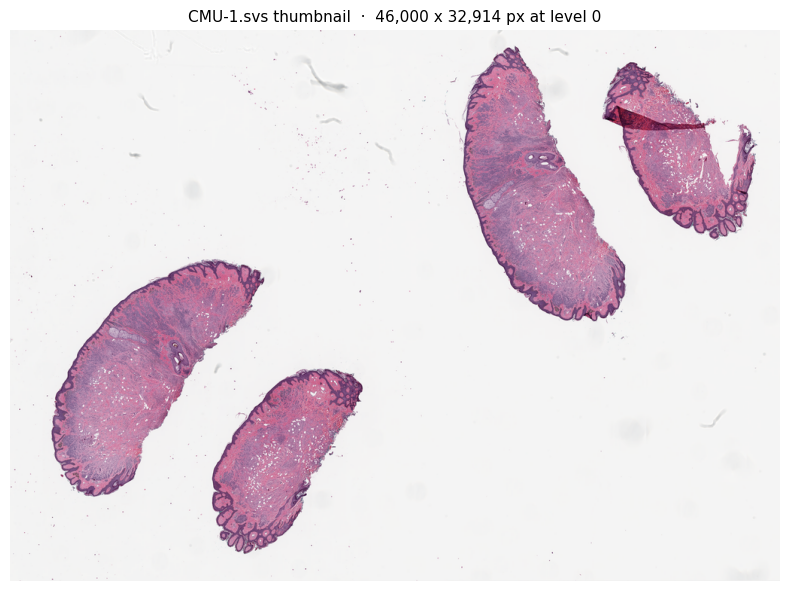

Thumbnail size: (733, 1024, 3)
Scale factors: x=0.02226  y=0.02227


In [4]:
THUMB_SIZE = (1024, 1024)
thumbnail  = slide.get_thumbnail(THUMB_SIZE)
thumb_np   = np.array(thumbnail)

# Scale factors for converting slide pixel coordinates to thumbnail pixel coordinates
W0, H0 = slide.dimensions  # level 0 dimensions
scale_x = thumb_np.shape[1] / W0
scale_y = thumb_np.shape[0] / H0

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.imshow(thumb_np)
ax.set_title(f'CMU-1.svs thumbnail  ·  {W0:,} x {H0:,} px at level 0',
             fontname='DejaVu Sans', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'slide_thumbnail.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Thumbnail size: {thumb_np.shape}")
print(f"Scale factors: x={scale_x:.5f}  y={scale_y:.5f}")

## Cell 5: Select the working level

We need to choose which pyramid level to extract patches from.

Phikon-v2 was trained on patches at 1.0 microns per pixel (MPP). CMU-1 is 0.499 um/px at level 0. The closest level to 1.0 um/px is level 1 (approximately 0.998 um/px at 2x downsampling).

Working at 1.0 MPP matches the SurGen pre-extracted embeddings, which were also extracted at 1.0 MPP. This is important for consistency.

At this level the slide is approximately 23,000 x 16,500 pixels.

In [5]:
TARGET_MPP = 1.0   # microns per pixel - matches SurGen extraction

# Find the level with MPP closest to target
best_level = 0
best_diff  = float('inf')
for lvl in range(slide.level_count):
    ds  = slide.level_downsamples[lvl]
    mpp = mpp_x * ds
    print(f"  Level {lvl}: {mpp:.4f} um/px  (diff from {TARGET_MPP}: {abs(mpp-TARGET_MPP):.4f})")
    if abs(mpp - TARGET_MPP) < best_diff:
        best_diff  = abs(mpp - TARGET_MPP)
        best_level = lvl

WORK_LEVEL  = best_level
WORK_DIMS   = slide.level_dimensions[WORK_LEVEL]
WORK_DS     = slide.level_downsamples[WORK_LEVEL]
WORK_MPP    = mpp_x * WORK_DS

print(f"\nSelected: level {WORK_LEVEL}")
print(f"  Dimensions: {WORK_DIMS[0]:,} x {WORK_DIMS[1]:,} px")
print(f"  Downsample: {WORK_DS:.2f}x")
print(f"  MPP:        {WORK_MPP:.4f} um/px")

  Level 0: 0.4990 um/px  (diff from 1.0: 0.5010)
  Level 1: 1.9961 um/px  (diff from 1.0: 0.9961)
  Level 2: 7.9842 um/px  (diff from 1.0: 6.9842)

Selected: level 0
  Dimensions: 46,000 x 32,914 px
  Downsample: 1.00x
  MPP:        0.4990 um/px


## Cell 6: Otsu-based background filtering

WSIs contain large areas of white background - the glass slide outside the tissue section. We must exclude these tiles before embedding.

For TMA cores in Videos 3-4 we used a fixed threshold (mean > 243 OR std < 4). For WSIs we use **Otsu's method** - an automatic threshold that finds the optimal separation between foreground (tissue) and background (glass) based on the intensity histogram of each tile.

Otsu thresholding works on the grayscale version of the tile. A tile with a low Otsu threshold means the image has two distinct intensity clusters - tissue and background - and the tissue is well-defined. A tile where most pixels are near-white will have a high Otsu threshold or no meaningful separation.

We keep a tile if its Otsu threshold exceeds a minimum value (default: 10). Near-white background tiles will fail this test.

Global Otsu threshold (inverted): 65
In original space (pixel mean < 190 = background)


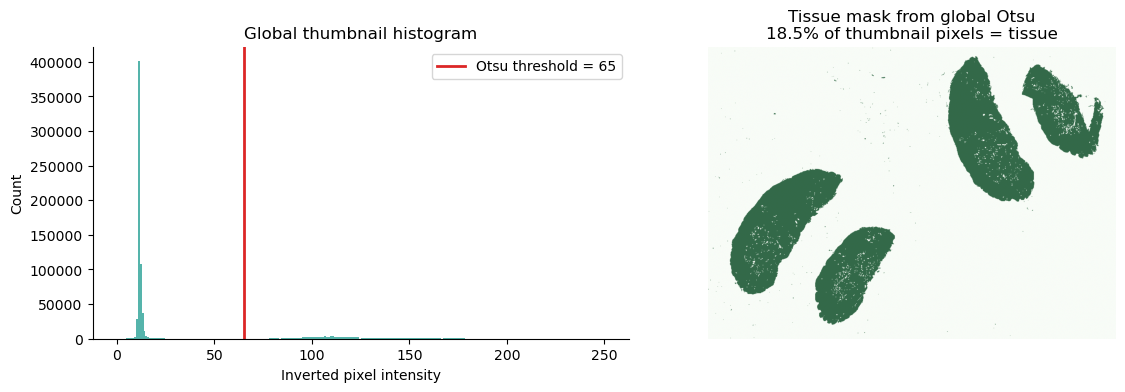

Saved: otsu_threshold.png


In [6]:
from PIL import ImageOps

TILE_SIZE  = 256
STRIDE     = 256

# Compute Otsu threshold on the whole-slide thumbnail
# Convert to grayscale, invert so tissue is bright
thumb_gray   = np.array(ImageOps.grayscale(thumbnail))
thumb_inv    = 255 - thumb_gray

# Otsu on the global histogram
hist, _      = np.histogram(thumb_inv.flatten(), bins=256, range=(0, 256))
hist_norm    = hist.astype(float) / hist.sum()
best_thresh  = 0
best_var     = 0.0
cum_w        = 0.0
cum_mean     = 0.0
total_mean   = np.sum(np.arange(256) * hist_norm)

for t in range(256):
    cum_w    += hist_norm[t]
    cum_mean += t * hist_norm[t]
    if cum_w == 0 or cum_w == 1:
        continue
    mean_bg   = cum_mean / cum_w
    mean_fg   = (total_mean - cum_mean) / (1 - cum_w)
    var_between = cum_w * (1 - cum_w) * (mean_bg - mean_fg) ** 2
    if var_between > best_var:
        best_var    = var_between
        best_thresh = t

GLOBAL_OTSU = best_thresh
print(f"Global Otsu threshold (inverted): {GLOBAL_OTSU}")
print(f"In original space (pixel mean < {255 - GLOBAL_OTSU} = background)")

# Visualize the threshold on the thumbnail histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

axes[0].hist(thumb_inv.flatten(), bins=256, color='#0D9488', alpha=0.7)
axes[0].axvline(GLOBAL_OTSU, color='#DC2626', linewidth=2,
                label=f'Otsu threshold = {GLOBAL_OTSU}')
axes[0].set_xlabel('Inverted pixel intensity', fontname='DejaVu Sans')
axes[0].set_ylabel('Count', fontname='DejaVu Sans')
axes[0].set_title('Global thumbnail histogram', fontname='DejaVu Sans')
axes[0].legend()
for sp in ['top', 'right']:
    axes[0].spines[sp].set_visible(False)

# Apply threshold to thumbnail for visual check
tissue_mask = thumb_inv > GLOBAL_OTSU
axes[1].imshow(tissue_mask, cmap='Greens', alpha=0.8)
axes[1].set_title(f'Tissue mask from global Otsu\n'
                  f'{tissue_mask.mean():.1%} of thumbnail pixels = tissue',
                  fontname='DejaVu Sans')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'otsu_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: otsu_threshold.png")

## Cell 7: Tile the WSI and filter background

We slide a 256x256 window across the working level with stride 256 (non-overlapping). For each tile position we:
1. Read the tile from disk using `slide.read_region()`
2. Apply the Otsu background filter
3. Keep the tile and its level-0 pixel coordinates if it passes

`read_region(location, level, size)` - note that `location` is always in **level-0 pixel coordinates**, even when reading from a higher level. We convert tile positions accordingly.

We store coordinates in level-0 pixel space so they remain valid regardless of which level we read from.

In [7]:
W_work, H_work = WORK_DIMS

tiles_pil = []
coords_l0 = []
n_total   = 0
n_kept    = 0

# Tissue threshold in original (non-inverted) pixel space
# A tile is tissue if its mean pixel value < TISSUE_MEAN_MAX
TISSUE_MEAN_MAX = 255 - GLOBAL_OTSU

print(f"Tiling at level {WORK_LEVEL} ({WORK_DIMS[0]:,} x {WORK_DIMS[1]:,} px)")
print(f"Background filter: mean pixel > {TISSUE_MEAN_MAX} = background, excluded")
print(f"Expected tiles before filtering: {(W_work//STRIDE) * (H_work//STRIDE):,}")
print("Filtering ...")

for y in tqdm(range(0, H_work - TILE_SIZE + 1, STRIDE), desc="Rows"):
    for x in range(0, W_work - TILE_SIZE + 1, STRIDE):
        n_total += 1
        x_l0 = int(x * WORK_DS)
        y_l0 = int(y * WORK_DS)

        tile = slide.read_region(
            (x_l0, y_l0), WORK_LEVEL, (TILE_SIZE, TILE_SIZE)
        ).convert('RGB')

        tile_np = np.array(tile)
        if tile_np.mean() < TISSUE_MEAN_MAX:
            tiles_pil.append(tile)
            coords_l0.append((x_l0, y_l0))
            n_kept += 1

coords_l0 = np.array(coords_l0)

print(f"\nTotal tiles scanned: {n_total:,}")
print(f"Tissue tiles kept:   {n_kept:,}  ({n_kept/n_total:.1%})")
print(f"Background excluded: {n_total - n_kept:,}")

Tiling at level 0 (46,000 x 32,914 px)
Background filter: mean pixel > 190 = background, excluded
Expected tiles before filtering: 22,912
Filtering ...


Rows: 100%|██████████| 128/128 [00:55<00:00,  2.31it/s]


Total tiles scanned: 22,912
Tissue tiles kept:   4,369  (19.1%)
Background excluded: 18,543


## Cell 8: Visualize the tile grid on the thumbnail

We overlay the kept tile positions on the slide thumbnail. Each kept tile is shown as a small colored rectangle. This confirms the background filter is working correctly - tiles should cover the tissue regions and be absent from the white glass areas.

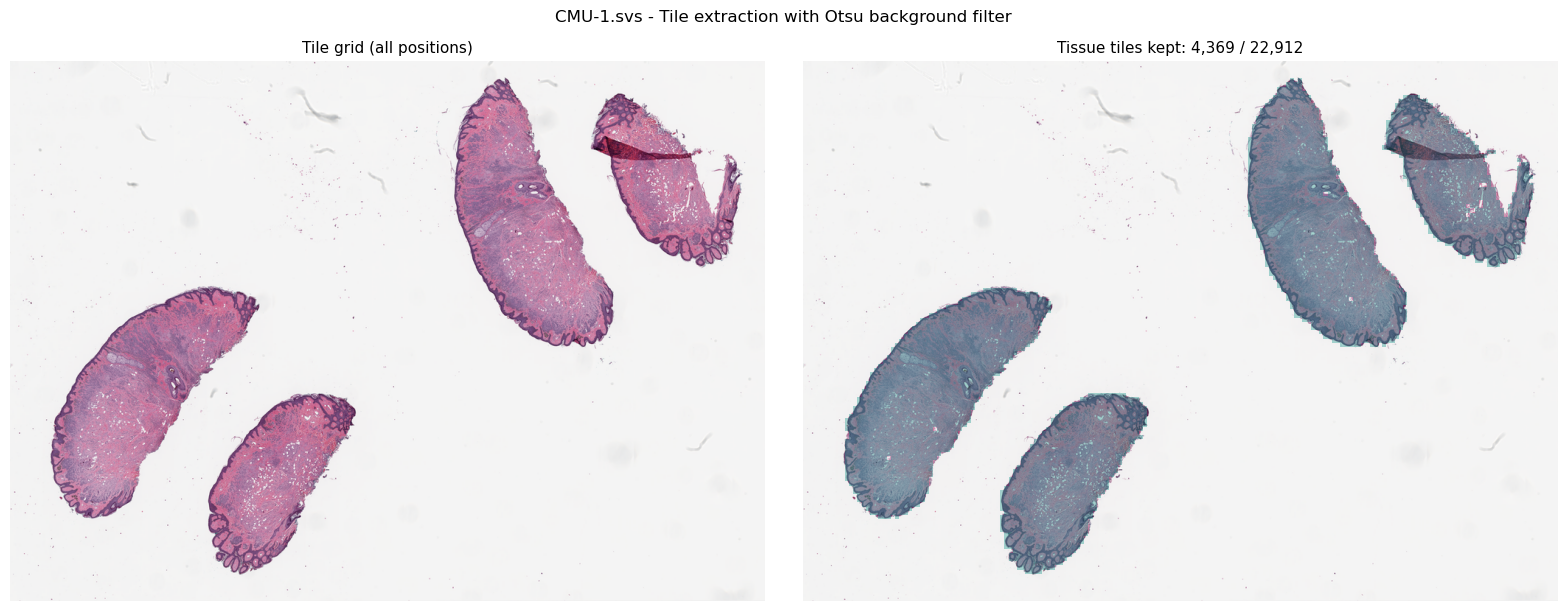

Saved: tile_grid.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Left: thumbnail with all tile grid
ax = axes[0]
ax.imshow(thumb_np)
# Draw grid lines
tile_in_thumb_w = TILE_SIZE * WORK_DS * scale_x
tile_in_thumb_h = TILE_SIZE * WORK_DS * scale_y
ax.set_title('Tile grid (all positions)',
             fontname='DejaVu Sans', fontsize=11)
ax.axis('off')

# Right: thumbnail with kept tiles highlighted
ax = axes[1]
ax.imshow(thumb_np)
for x_l0, y_l0 in coords_l0:
    tx = x_l0 * scale_x
    ty = y_l0 * scale_y
    tw = TILE_SIZE * WORK_DS * scale_x
    th = TILE_SIZE * WORK_DS * scale_y
    rect = mpatches.Rectangle(
        (tx, ty), tw, th,
        linewidth=0, edgecolor='none',
        facecolor='#0D9488', alpha=0.35
    )
    ax.add_patch(rect)
ax.set_title(f'Tissue tiles kept: {n_kept:,} / {n_total:,}',
             fontname='DejaVu Sans', fontsize=11)
ax.axis('off')

plt.suptitle('CMU-1.svs - Tile extraction with Otsu background filter',
             fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tile_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tile_grid.png")

## Cell 9: Load Phikon-v2 and extract embeddings

Same pipeline as Videos 2, 3, and 4. We process tiles in batches of 32.

**Time estimate:** Number of kept tissue tiles divided by 32 batches, roughly 2-4 minutes depending on tissue coverage.

In [9]:
BATCH_SIZE = 32

print("Loading Phikon-v2 ...")
processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2")
model     = AutoModel.from_pretrained("owkin/phikon-v2")
model     = model.to(device)
model.eval()
print(f"Model loaded on: {device}")
print(f"\nExtracting embeddings for {n_kept:,} tiles ...")

all_embeddings = []
n_batches = int(np.ceil(n_kept / BATCH_SIZE))

for i in tqdm(range(n_batches), desc="Embedding batches"):
    batch    = tiles_pil[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]
    inputs   = processor(images=batch, return_tensors="pt").to(device)
    with torch.no_grad():
        out  = model(**inputs)
    embs = out.last_hidden_state[:, 0, :].cpu().numpy()
    all_embeddings.append(embs)

embeddings = np.vstack(all_embeddings)  # (N_kept, 1024)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Coordinates shape: {coords_l0.shape}")

Loading Phikon-v2 ...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Model loaded on: cuda

Extracting embeddings for 4,369 tiles ...


Embedding batches: 100%|██████████| 137/137 [01:02<00:00,  2.21it/s]


Embeddings shape: (4369, 1024)
Coordinates shape: (4369, 2)


## Cell 10: Save embeddings and coordinates

We save in `.npz` format - the same structure we will use when loading the SurGen pre-extracted embeddings in Notebook 2. Each slide gets:
- `embeddings`: (N_tiles, 1024) float32
- `coords`: (N_tiles, 2) int - (x, y) in level-0 pixel space
- Metadata stored as separate arrays

This format allows you to reconstruct the spatial map at any time without re-running Phikon-v2.

In [10]:
np.savez(
    EMBED_OUT,
    embeddings  = embeddings.astype(np.float32),
    coords      = coords_l0.astype(np.int32),
    slide_dims  = np.array(slide.dimensions),
    work_level  = np.array([WORK_LEVEL]),
    work_ds     = np.array([WORK_DS]),
    tile_size   = np.array([TILE_SIZE]),
    mpp         = np.array([WORK_MPP])
)

size_mb = os.path.getsize(EMBED_OUT) / 1e6
print(f"Saved: {EMBED_OUT}")
print(f"File size: {size_mb:.1f} MB")
print(f"Contents:")
print(f"  embeddings: {embeddings.shape}  float32")
print(f"  coords:     {coords_l0.shape}  int32 (level-0 pixel space)")
print(f"  mpp:        {WORK_MPP:.4f} um/px")

Saved: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video5a\CMU1_embeddings.npz
File size: 17.9 MB
Contents:
  embeddings: (4369, 1024)  float32
  coords:     (4369, 2)  int32 (level-0 pixel space)
  mpp:        0.4990 um/px


## Cell 11: UMAP of patch embeddings colored by spatial position

We project the embeddings to 2D with UMAP and color each point by its position on the slide - top (blue), bottom (red), left (teal), right (amber). If the embeddings capture tissue structure, spatially proximate tiles should cluster together in UMAP space, and different tissue regions should occupy different regions of the embedding space.

This visualization connects the spatial layout of the slide to the structure of the embedding space.

Subsampled 3000 tiles for UMAP (from 4,369)
Running UMAP ...


c:\Users\m6sbhatt\AppData\Local\anaconda3\envs\torch-gpu-pathology\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


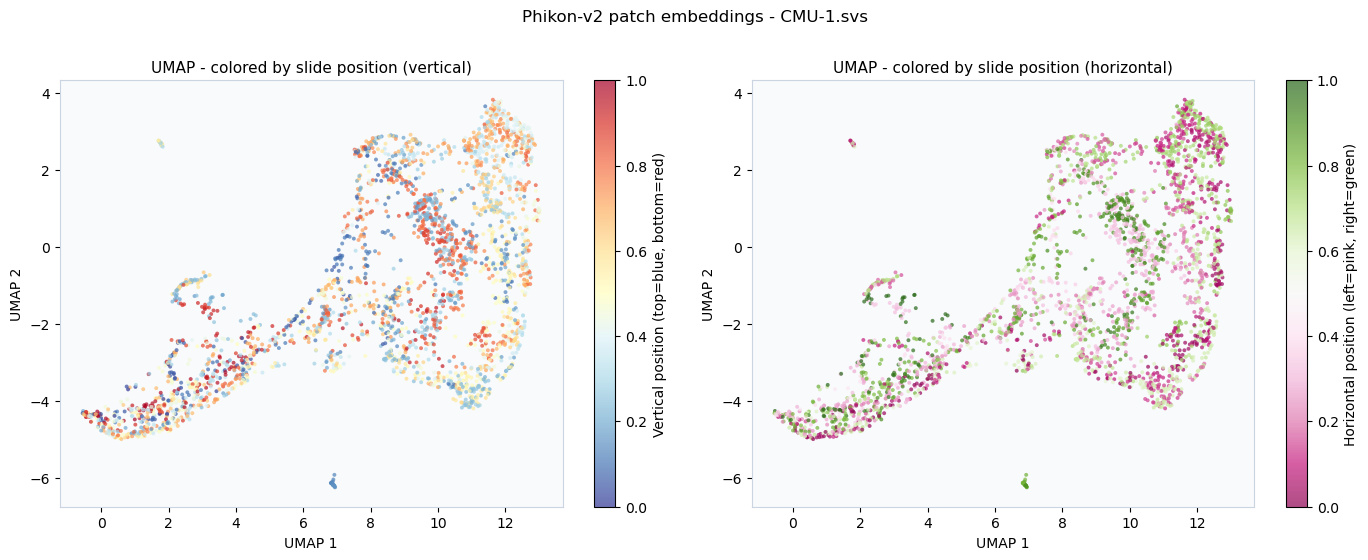

Saved: umap_spatial.png


In [11]:
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "umap-learn", "--break-system-packages", "-q"], check=True)
    import umap

# Subsample if too many tiles for fast UMAP
MAX_UMAP = 3000
if len(embeddings) > MAX_UMAP:
    rng      = np.random.default_rng(42)
    idx      = rng.choice(len(embeddings), MAX_UMAP, replace=False)
    emb_sub  = embeddings[idx]
    crd_sub  = coords_l0[idx]
    print(f"Subsampled {MAX_UMAP} tiles for UMAP (from {len(embeddings):,})")
else:
    emb_sub = embeddings
    crd_sub = coords_l0

print("Running UMAP ...")
reducer     = umap.UMAP(n_neighbors=20, min_dist=0.1, metric='cosine',
                         random_state=42)
umap_coords = reducer.fit_transform(emb_sub)

# Color by vertical position (y coordinate)
y_norm = (crd_sub[:, 1] - crd_sub[:, 1].min()) / \
         (crd_sub[:, 1].max() - crd_sub[:, 1].min() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

# Left: UMAP colored by vertical position
ax = axes[0]
ax.set_facecolor('#F8FAFC')
sc = ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
                c=y_norm, cmap='RdYlBu_r', s=8, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label='Vertical position (top=blue, bottom=red)')
ax.set_title('UMAP - colored by slide position (vertical)',
             fontname='DejaVu Sans', fontsize=11)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=10)
for sp in ax.spines.values():
    sp.set_edgecolor('#CBD5E1')

# Right: color by horizontal position
x_norm = (crd_sub[:, 0] - crd_sub[:, 0].min()) / \
         (crd_sub[:, 0].max() - crd_sub[:, 0].min() + 1e-8)
ax = axes[1]
ax.set_facecolor('#F8FAFC')
sc = ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
                c=x_norm, cmap='PiYG', s=8, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label='Horizontal position (left=pink, right=green)')
ax.set_title('UMAP - colored by slide position (horizontal)',
             fontname='DejaVu Sans', fontsize=11)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=10)
for sp in ax.spines.values():
    sp.set_edgecolor('#CBD5E1')

plt.suptitle('Phikon-v2 patch embeddings - CMU-1.svs',
             fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_spatial.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_spatial.png")

## Cell 12: Unsupervised tissue compartment map

We do not have tissue type labels for CMU-1. But we can use KMeans clustering on the embeddings to group tiles into clusters that likely correspond to distinct tissue compartments. The number of clusters matches the 4 tissue regions visible in CMU-1.

We then reconstruct those cluster assignments spatially on the slide thumbnail - each tile position is colored by its cluster. This is the same kind of tissue map that Notebook 2 produces for colorectal cancer slides, but using unsupervised clustering instead of a trained classifier.

Clustering 4,369 tiles into 4 groups ...
Done.
  Cluster 0: 1,450 tiles
  Cluster 1: 866 tiles
  Cluster 2: 1,060 tiles
  Cluster 3: 993 tiles


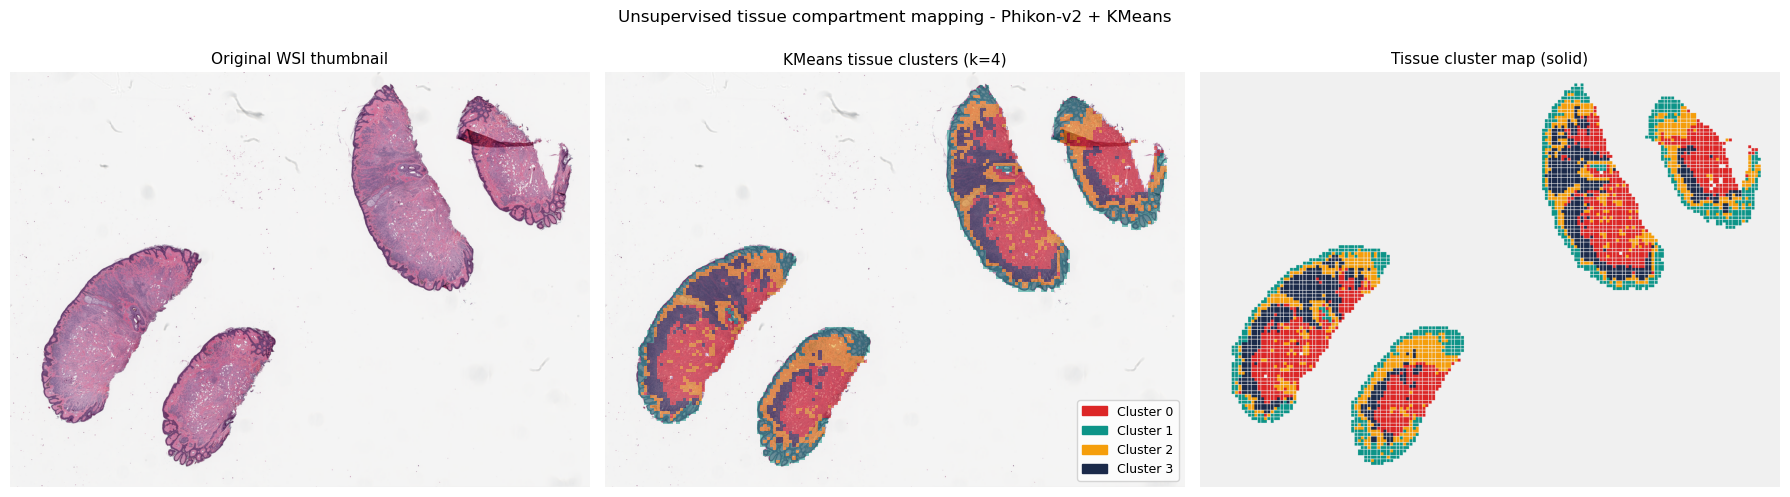

Saved: tissue_cluster_map.png


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

N_CLUSTERS = 4  # CMU-1 has 4 tissue regions

# Scale embeddings before clustering
scaler     = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)

print(f"Clustering {len(embeddings):,} tiles into {N_CLUSTERS} groups ...")
km      = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = km.fit_predict(emb_scaled)
print("Done.")
for c in range(N_CLUSTERS):
    print(f"  Cluster {c}: {(cluster_labels == c).sum():,} tiles")

# Cluster colors
CLUSTER_COLORS = ['#DC2626', '#0D9488', '#F59E0B', '#1B2A4A']

# Build spatial map on thumbnail
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# Panel 1: original thumbnail
axes[0].imshow(thumb_np)
axes[0].set_title('Original WSI thumbnail', fontname='DejaVu Sans', fontsize=11)
axes[0].axis('off')

# Panel 2: cluster map overlaid
axes[1].imshow(thumb_np)
for (x_l0, y_l0), clust in zip(coords_l0, cluster_labels):
    tx = x_l0 * scale_x
    ty = y_l0 * scale_y
    tw = TILE_SIZE * WORK_DS * scale_x
    th = TILE_SIZE * WORK_DS * scale_y
    rect = mpatches.Rectangle(
        (tx, ty), tw, th, linewidth=0,
        facecolor=CLUSTER_COLORS[clust], alpha=0.5
    )
    axes[1].add_patch(rect)
legend_patches = [mpatches.Patch(color=c, label=f'Cluster {i}')
                  for i, c in enumerate(CLUSTER_COLORS)]
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=9)
axes[1].set_title(f'KMeans tissue clusters (k={N_CLUSTERS})',
                  fontname='DejaVu Sans', fontsize=11)
axes[1].axis('off')

# Panel 3: cluster map only (solid color)
map_img = np.ones((*thumb_np.shape[:2], 3), dtype=np.uint8) * 240
for (x_l0, y_l0), clust in zip(coords_l0, cluster_labels):
    tx  = int(x_l0 * scale_x)
    ty  = int(y_l0 * scale_y)
    tw  = max(1, int(TILE_SIZE * WORK_DS * scale_x))
    th  = max(1, int(TILE_SIZE * WORK_DS * scale_y))
    rgb = tuple(int(CLUSTER_COLORS[clust].lstrip('#')[i:i+2], 16) for i in (0,2,4))
    map_img[ty:ty+th, tx:tx+tw] = rgb

axes[2].imshow(map_img)
axes[2].set_title('Tissue cluster map (solid)',
                  fontname='DejaVu Sans', fontsize=11)
axes[2].axis('off')

plt.suptitle('Unsupervised tissue compartment mapping - Phikon-v2 + KMeans',
             fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tissue_cluster_map.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tissue_cluster_map.png")

## Cell 13: Show sample tiles from each cluster

For each cluster we display the 6 tiles closest to the cluster centroid - the most representative tiles for that group. This lets us visually interpret what each cluster represents: which one is epithelium, which is stroma, which is background/artifact.

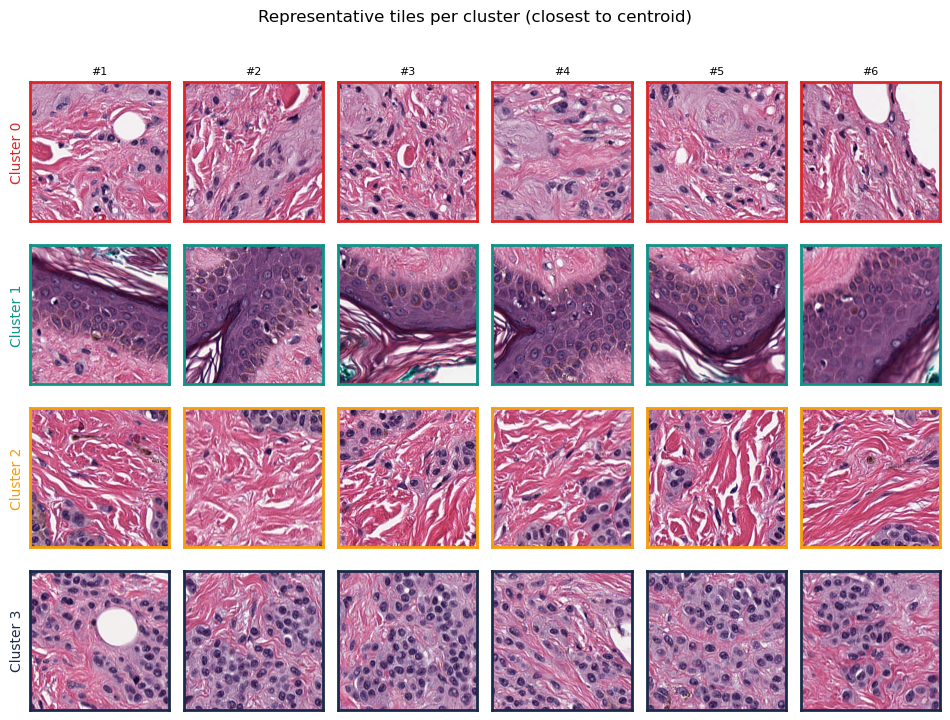

Saved: cluster_tiles.png


In [13]:
TOP_K = 6
centroids = km.cluster_centers_  # (N_CLUSTERS, 1024) in scaled space

fig, axes = plt.subplots(N_CLUSTERS, TOP_K,
                          figsize=(TOP_K * 1.6, N_CLUSTERS * 1.8))
fig.patch.set_facecolor('white')

for c in range(N_CLUSTERS):
    # Indices of tiles in this cluster
    cluster_idx = np.where(cluster_labels == c)[0]

    # Distance to centroid for each tile in cluster
    dists = np.linalg.norm(
        emb_scaled[cluster_idx] - centroids[c], axis=1
    )
    # Top-K closest to centroid
    top_idx = cluster_idx[np.argsort(dists)[:TOP_K]]

    axes[c, 0].set_ylabel(f'Cluster {c}', fontsize=10,
                           fontname='DejaVu Sans',
                           color=CLUSTER_COLORS[c], rotation=90, labelpad=4)

    for k, tile_idx in enumerate(top_idx):
        ax = axes[c, k]
        ax.imshow(np.array(tiles_pil[tile_idx]))
        for sp in ax.spines.values():
            sp.set_edgecolor(CLUSTER_COLORS[c])
            sp.set_linewidth(2)
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0:
            ax.set_title(f'#{k+1}', fontsize=8, fontname='DejaVu Sans')

plt.suptitle('Representative tiles per cluster (closest to centroid)',
             fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cluster_tiles.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cluster_tiles.png")

## Summary

What this notebook demonstrated:

1. How to open a WSI with OpenSlide and navigate its pyramid structure
2. How to select the appropriate resolution level for analysis (1.0 um/px = 10x)
3. How to tile a WSI and filter background using Otsu thresholding
4. How to extract Phikon-v2 embeddings for each tissue tile with spatial coordinates
5. How to save embeddings in a structured format (npz) with coordinates
6. How to visualize: tile grid, UMAP colored by position, unsupervised tissue map

**The output file** `CMU1_embeddings.npz` contains embeddings + level-0 pixel coordinates. This is exactly the format provided by the SurGen pre-extracted embeddings we use in Notebook 2.

**In Notebook 2**, we load 427 SurGen colorectal cancer slides worth of pre-extracted UNI embeddings in the same Zarr format, match them to the SR386_labels.csv survival data, and perform spatial analysis of the tumor microenvironment.

Code and notebooks: github.com/bnsreenu